In [1]:
import demes
import msprime
import numpy as np
import os

import h2py
from h2py.utils import timestamp

In [2]:
# Simulation parameters
L = 1_000_000
n_reps = 20
n_samples = 1  # per population
u = 1.5e-8
r = 1e-8
r_bins = np.logspace(-6, -2, 17)
samples = {"pop0": n_samples}
depth = 5

# File names
pop_file = "data/populations.txt"
rec_map_file = "data/rec_map.txt"
bed_file = "data/coverage.bed"


def demographic_model():
    b = demes.Builder()
    b.add_deme("anc", epochs=[dict(start_size=1e4, end_time=3e3)])
    b.add_deme("pop0", ancestors=["anc"], epochs=[dict(start_size=1e4)])
    b.add_deme("pop1", ancestors=["anc"], epochs=[dict(start_size=1e4)])
    b.add_migration(demes=["pop0", "pop1"], rate=1e-4)
    g = b.resolve()
    return g

g = demographic_model()

In [11]:
def write_pop_file():
    with open(pop_file, "w") as fout:
        fout.write("sample\tpop\n")
        idx = 0
        for pop in samples:
            for sidx in range(n_samples):
                fout.write(f"tsk_{idx}\t{pop}\n")
                idx += 1


def write_rec_map_file():
    with open(rec_map_file, "w") as fout:
        fout.write("chrom\tPosition(bp)\tMap(cM)\n")
        fout.write("none\t0\t0\n")
        fout.write(f"none\t{L}\t{100*r*L}\n")


def write_bed_file():
    with open(bed_file, "w") as fout:
        fout.write(f"none\t0\t{L}\n")


write_pop_file()
write_rec_map_file()
write_bed_file()

In [12]:
def run_sim(g, i):
    demog = msprime.Demography.from_demes(g)
    ts = msprime.sim_ancestry(
        samples,
        demography=demog,
        sequence_length=L,
        recombination_rate=r,
    )
    ts = msprime.sim_mutations(ts, rate=u, model="binary")
    # Generate a reference sequence
    ref_seq = np.random.choice(["A", "C", "T", "G"], size=L)
    fasta_file = f"data/reference.{i}.fasta"
    h2py.utils.write_fasta_file(fasta_file, [ref_seq], ["reference"])
    sam_file = f"data/sample.{i}.sam"
    h2py.simulation.generate_sam_file(
        ts,
        sam_file,
        ref_seq,
        ref_name="reference",
        sample_name="sample",
        depth=depth,
        report=100000,
    )
    print(timestamp(), f"Simulated replicate {i}")

for i in range(n_reps):
    run_sim(g, i)

<2026-07-09 10:51:47> Wrote read 0; depth 3.8e-05
<2026-07-09 10:51:50> Wrote read 99999; depth 4.998153
<2026-07-09 10:51:50> Finished writing data/sample.0.sam
<2026-07-09 10:51:50> Simulated replicate 0
<2026-07-09 10:51:51> Wrote read 0; depth 9.7e-05
<2026-07-09 10:51:54> Wrote read 99999; depth 4.99369
<2026-07-09 10:51:54> Finished writing data/sample.1.sam
<2026-07-09 10:51:54> Simulated replicate 1
<2026-07-09 10:51:54> Wrote read 0; depth 3.7e-05
<2026-07-09 10:51:57> Wrote read 99999; depth 4.994947
<2026-07-09 10:51:57> Finished writing data/sample.2.sam
<2026-07-09 10:51:57> Simulated replicate 2
<2026-07-09 10:51:57> Wrote read 0; depth 7.9e-05
<2026-07-09 10:52:00> Wrote read 99999; depth 4.992035
<2026-07-09 10:52:00> Finished writing data/sample.3.sam
<2026-07-09 10:52:00> Simulated replicate 3
<2026-07-09 10:52:01> Wrote read 0; depth 5.9e-05
<2026-07-09 10:52:04> Wrote read 99999; depth 4.993691
<2026-07-09 10:52:04> Finished writing data/sample.4.sam
<2026-07-09 10:

In [ ]:
# Use ATLAS to compute genotype probabilities
for i in range(n_reps):
    !samtools view -b "data/sample.{i}.sam" | samtools sort -o "data/sample.{i}.bam"
    !atlas call --bam "data/sample.{i}.bam" --fasta "data/reference.{i}.fasta" --method Bayesian \
        --sampleName tsk_0 --out "data/sample.{i}"

atlas: /lib/x86_64-linux-gnu/libhts.so.3: no version information available (required by atlas)

                   ATLAS 2.0.3
                  -------------

     https://bitbucket.org/wegmannlab/atlas

 Commit 7ab31971feabf9a9fd07409cedcc56d1b86e2d4d

   - Used executable: atlas
   - Interpreting 'call' as name of task.
   - Will write log to file 'data/sample.0.log'. (use 'noLogFile' to supress or 'logFile' to specify the file-name)
   - Calling genotypes (task = call):
      - Writing output files with prefix 'data/sample.0'. (parameter 'out')
      - Initializing random generator with seed 1'783'612'375'719. (use 'fixedSeed' or 'addToSeed' to specify)
      - Will use the following filters on reads:
         - Mapped length: restrict to range [0,500]. (parameter 'filterMappingLength')
         - Read length: keep all. (use 'filterReadLength' to limit)
         - Mapping quality: keep all. (use 'filterMQ' to limit)
         - Fragment length: keep all. (use 'filterFragmentLength' 

<2026-07-09 10:59:29> Preparing data ...
<2026-07-09 10:59:35> Prepared GenotypeProbMatrix (992560 sites, 1 samples, 1 pops)
<2026-07-09 10:59:35> Loaded map coordinates (1.2e-07 to 0.009999 M)
<2026-07-09 10:59:35> Computing statistics and denominators ...
<2026-07-09 10:59:35> Computed statistics and denominators.
<2026-07-09 10:59:35>     Done!
<2026-07-09 10:59:35> Preparing data ...
<2026-07-09 10:59:41> Prepared GenotypeProbMatrix (992310 sites, 1 samples, 1 pops)
<2026-07-09 10:59:41> Loaded map coordinates (4e-08 to 0.01 M)
<2026-07-09 10:59:41> Computing statistics and denominators ...
<2026-07-09 10:59:41> Computed statistics and denominators.
<2026-07-09 10:59:41>     Done!
<2026-07-09 10:59:41> Preparing data ...
<2026-07-09 10:59:47> Prepared GenotypeProbMatrix (992952 sites, 1 samples, 1 pops)
<2026-07-09 10:59:47> Loaded map coordinates (2.3e-07 to 0.01 M)
<2026-07-09 10:59:47> Computing statistics and denominators ...
<2026-07-09 10:59:47> Computed statistics and denomi

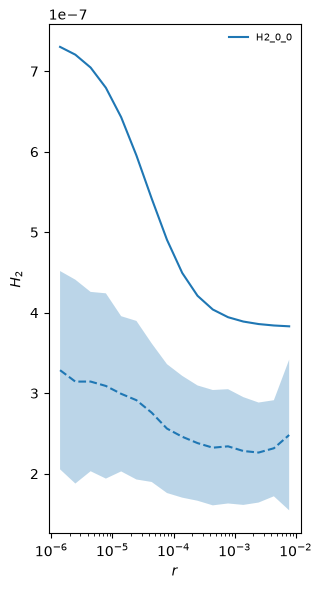

[0.00048241]
[0.00061793]


In [3]:
sums = {}
for i in range(n_reps):
    sums[i] = h2py.parsing.compute_h2_stats(
        vcf_file=f"data/sample.{i}_calls_maximumAPosteriori.vcf.gz",
        use_genotype_probs=True,
        pop_file=pop_file,
        bed_file=bed_file,
        rec_map_file=rec_map_file,
        r_bins=r_bins,
        report=True,
    )
boot_data = h2py.parsing.bootstrap_data(sums)
model = h2py.H2stats.from_demes(g, sampled_demes=["pop0"], u=u, r_bins=r_bins)
h2py.plotting.plot_h2_curves_comp(
    model,
    boot_data["means"],
    boot_data["varcovs"],
    r_bins=boot_data["bins"], cols=2
)

print(boot_data["means"][-1])
print(model.data[-1])

In [ ]:
varcovs = boot_data["varcovs"]
arr = varcovs[0]
arr

In [ ]:
arr[None, None]